In [2]:
import numpy as np


class MyOwnLogisticRegressionGD:

    def __init__(self, learning_rate=0.001, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # gradient descent
        for _ in range(self.n_iters):
            # approximate y with linear combination of weights and x, plus bias
            linear_model = np.dot(X, self.weights) + self.bias
            # apply sigmoid function
            y_predicted = self._sigmoid(linear_model)

            # compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            # update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))


Accuracy: 0.9


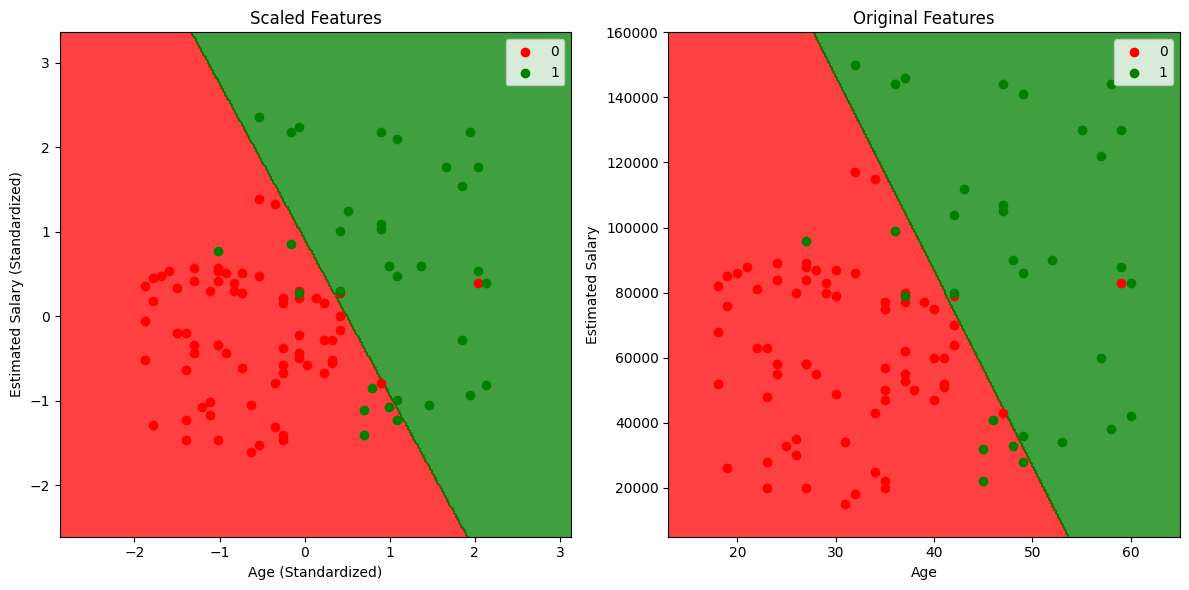

In [3]:
if __name__ == "__main__":

    import pandas as pd
    import matplotlib.pyplot as plt

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score
    from matplotlib.colors import ListedColormap

    # =========================
    # Load dataset
    # =========================

    data = pd.read_csv("Social_Network_Ads.csv")

    X_raw = data[["Age", "EstimatedSalary"]].values
    y = data["Purchased"].values

    # =========================
    # Feature Scaling
    # =========================

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # =========================
    # Train/Test Split
    # =========================

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.25, random_state=0
    )

    X_train_raw, X_test_raw, _, _ = train_test_split(
        X_raw, y, test_size=0.25, random_state=0
    )

    # =========================
    # Train Model
    # =========================

    model = MyOwnLogisticRegressionGD(learning_rate=0.01, n_iters=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))

    # =========================
    # Visualization
    # =========================

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    cmap = ListedColormap(("red", "green"))
    colors = ["red", "green"]

    # =========================================================
    # LEFT SUBPLOT : SCALED FEATURES
    # =========================================================

    ax = axes[0]

    X_set, y_set = X_test, y_test

    x_min, x_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
    y_min, y_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1

    X1, X2 = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid = np.c_[X1.ravel(), X2.ravel()]
    Z = model.predict(grid).reshape(X1.shape)

    ax.contourf(X1, X2, Z, alpha=0.75, cmap=cmap)

    for i, label in enumerate(np.unique(y_set)):
        ax.scatter(
            X_set[y_set == label, 0],
            X_set[y_set == label, 1],
            color=colors[i],
            label=label,
        )

    ax.set_title("Scaled Features")
    ax.set_xlabel("Age (Standardized)")
    ax.set_ylabel("Estimated Salary (Standardized)")
    ax.legend()

    # =========================================================
    # RIGHT SUBPLOT : ORIGINAL FEATURES
    # =========================================================

    ax = axes[1]

    X_set, y_set = X_test_raw, y_test

    x_min, x_max = X_set[:, 0].min() - 5, X_set[:, 0].max() + 5
    y_min, y_max = X_set[:, 1].min() - 10000, X_set[:, 1].max() + 10000

    X1, X2 = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid_raw = np.c_[X1.ravel(), X2.ravel()]

    # transform before prediction
    grid_scaled = scaler.transform(grid_raw)

    Z = model.predict(grid_scaled).reshape(X1.shape)

    ax.contourf(X1, X2, Z, alpha=0.75, cmap=cmap)

    for i, label in enumerate(np.unique(y_set)):
        ax.scatter(
            X_set[y_set == label, 0],
            X_set[y_set == label, 1],
            color=colors[i],
            label=label,
        )

    ax.set_title("Original Features")
    ax.set_xlabel("Age")
    ax.set_ylabel("Estimated Salary")
    ax.legend()

    plt.tight_layout()
    plt.show()

Accuracy: 1.0000


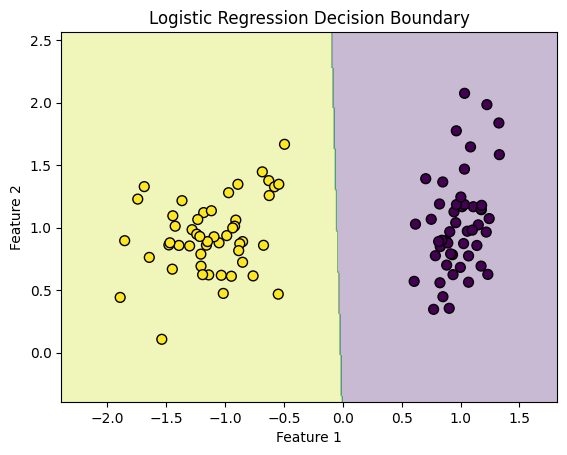

In [4]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate a simple classification dataset
X, y = datasets.make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=1,
    n_clusters_per_class=1,
)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the logistic regression model
model = MyOwnLogisticRegressionGD(learning_rate=0.01, n_iters=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


# Visualize the results
def plot_decision_boundary(X, y, model):
    # Define the bounds of the plot
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    # Make predictions on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Create a contour plot
    plt.contourf(xx, yy, Z, alpha=0.3)

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=50)
    plt.title("Logistic Regression Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# Plot the decision boundary
plot_decision_boundary(X, y, model)

In [5]:
model.__dict__

{'lr': 0.01,
 'n_iters': 1000,
 'weights': array([-2.13251472, -0.0648104 ]),
 'bias': -0.04111381288864607}